# 1. Generate Contrastive Examples (for Contrastive Learning)

In [1]:
from datasets import load_dataset

We are going to use [GLUE benchmark](https://gluebenchmark.com/) - General Language Understanding Evaluation.  
One of the tasks in the benchmark is Multi-Genre Natural Language Inference:

In [2]:
train_dataset = load_dataset(
    "nyu-mll/glue", # benchmark
    "mnli", # task
    split="train"
)

In [3]:
train_dataset

Dataset({
    features: ['premise', 'hypothesis', 'label', 'idx'],
    num_rows: 392702
})

In [4]:
# Labels:
# 0 = entailment
# 1 = neutral
# 2 = contradiction
train_dataset[2050]

{'premise': 'THE MEANING OF THE PRESENCE REQUIREMENT',
 'hypothesis': 'The Meaning of the Presence Suggestion',
 'label': 2,
 'idx': 2050}

In [5]:
train_dataset = train_dataset.select_columns(
    ["premise", "hypothesis", "label"]
)
# Or `trainer` will complain about `idx`

# 2. Train Model

In [6]:
from sentence_transformers import SentenceTransformer

In [7]:
embedding_model = SentenceTransformer(
    "answerdotai/ModernBERT-large"
)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
from sentence_transformers.sentence_transformer import losses

In [9]:
# Let's start from a "historical" loss function. Just an educational example.
train_loss = losses.SoftmaxLoss(
    model=embedding_model,
    embedding_dimension=embedding_model.get_embedding_dimension(),
    num_labels=3
)

Before we go and train our model, we need to provide eval using __Semantic Textual Similarity Benchmark__ (stsb).

In [10]:
from sentence_transformers.sentence_transformer.evaluation import EmbeddingSimilarityEvaluator

In [11]:
val_sts = load_dataset("nyu-mll/glue", "stsb", split="validation")

In [12]:
val_sts

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 1500
})

In [13]:
# "label" is "similarity". From 0 to 5.
val_sts[37]

{'sentence1': 'A man plays the piano.',
 'sentence2': 'A man is playing a piano.',
 'label': 5.0,
 'idx': 37}

In [14]:
evaluator = EmbeddingSimilarityEvaluator(
    sentences1=val_sts["sentence1"],
    sentences2=val_sts["sentence2"],
    scores=[score/5 for score in val_sts["label"]],
    main_similarity="cosine",
)

Now that we have our evaluator, we can define training arguments and start training process.

In [15]:
from sentence_transformers.sentence_transformer import SentenceTransformerTrainingArguments, SentenceTransformerTrainer

In [16]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [17]:
args = SentenceTransformerTrainingArguments(
    output_dir="data/base_embedding_model",
    num_train_epochs=1,
    
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    
    bf16=True,
    fp16=False,
    
    warmup_steps=1000,
    eval_steps=1000,
    logging_steps=1000
)

In [18]:
trainer = SentenceTransformerTrainer(
    model=embedding_model,
    args=args,
    train_dataset=train_dataset,
    loss=train_loss,
    evaluator=evaluator
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [19]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
Column 'hypothesis' is at index 1, whereas a column with this name is usually expected at index 0. Note that the column order can be important for some losses, e.g. MultipleNegativesRankingLoss will always consider the first column as the anchor and the second as the positive, regardless of the dataset column names. Consider renaming the columns to match the expected order, e.g.:
dataset = dataset.select_columns(['hypothesis', 'entailment', 'contradiction'])


Step,Training Loss
1000,0.841598
2000,0.660798
3000,0.617769
4000,0.590667
5000,0.569091
6000,0.561344
7000,0.540930
8000,0.532438
9000,0.520429
10000,0.490567


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12272, training_loss=0.5727952536890062, metrics={'train_runtime': 1759.609, 'train_samples_per_second': 223.176, 'train_steps_per_second': 6.974, 'total_flos': 0.0, 'train_loss': 0.5727952536890062, 'epoch': 1.0})

In [20]:
evaluator(embedding_model)

{'pearson_cosine': 0.7821596307798877, 'spearman_cosine': 0.8076850960537917}

We care about only `pearson_cosine`. It is Pearson correlation across sentence pairs, between predicted cosine similarities and human similarity scores.

## Evaluation Benchmark

There are many benchmarks that that allow for the evaluation of embedding models. To unify the effort, MTEB (Massive Text Embedding Benchmark) was created. 

In [24]:
import mteb

In [27]:
tasks = mteb.get_tasks(tasks=["Banking77Classification"])

In [30]:
results = mteb.evaluate(model=embedding_model, tasks=tasks)

/home/dima/Projects/ai/.venv/lib/python3.11/site-packages/mteb/models/model_meta.py:956: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dimensions = model.get_sentence_embedding_dimension()
/home/dima/Projects/ai/.venv/lib/python3.11/site-packages/mteb/models/model_meta.py:916: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embed_dim=model.get_sentence_embedding_dimension(),


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]

In [44]:
results.task_results[0].get_score(), results.task_results[0].task_name

(np.float64(0.740065), 'Banking77Classification')

I selected only one task for evaluation, but in real scenarios it would be beneficial to select multiple or everything from MTEB.

## Cosine Similarity Loss

There are two loss functions that are typically used and seem to perform generally well when training embedding models: **cosine similarity** and **multiple negative ranging (MNR) loss**.

In [47]:
from datasets import Dataset

In [48]:
mapping = {2: 0, 1: 0, 0: 1}

In [54]:
train_dataset_remapped = Dataset.from_dict({
    "sentence1": train_dataset["premise"],
    "sentence2": train_dataset["hypothesis"],
    "label": [float(mapping[label]) for label in train_dataset["label"]]
})

In [56]:
embedding_model = SentenceTransformer(
    "answerdotai/ModernBERT-large"
)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
train_loss = losses.CosineSimilarityLoss(
    model=embedding_model
)

In [58]:
args = SentenceTransformerTrainingArguments(
    output_dir="data/base_embedding_model_cosine",
    num_train_epochs=1,
    
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    
    bf16=True,
    fp16=False,
    
    warmup_steps=1000,
    eval_steps=1000,
    logging_steps=1000
)

In [59]:
trainer = SentenceTransformerTrainer(
    model=embedding_model,
    args=args,
    train_dataset=train_dataset_remapped,
    loss=train_loss,
    evaluator=evaluator
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [60]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss
1000,0.181969
2000,0.144952
3000,0.133483
4000,0.129682
5000,0.127598
6000,0.125107
7000,0.122207
8000,0.118675
9000,0.117329
10000,0.113745


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12272, training_loss=0.12783103427489081, metrics={'train_runtime': 1759.9739, 'train_samples_per_second': 223.129, 'train_steps_per_second': 6.973, 'total_flos': 0.0, 'train_loss': 0.12783103427489081, 'epoch': 1.0})

In [61]:
evaluator(embedding_model)

{'pearson_cosine': 0.7278844749780983, 'spearman_cosine': 0.7250266693877886}

## Multiple Negative Ranging (MNR) Loss

In case of **multiple negative ranking loss**, we use triplets that contain a pair of positive sentences and and additional unrelated sentence. We call unrelated sentence "negative" and assume it represent dissimilarity between the positive sentences.

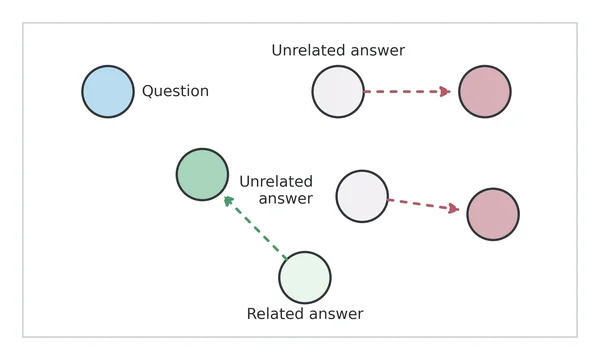


After having generated positive and negative pairs, we calculate their embeddings and apply cosine similarity. The similarity scores are then used to answer the question, are this pairs negative or positive? It is eventually treated as classification task and we can use cross-entropy to optimize the model.

In [63]:
mnli = train_dataset.filter(lambda x: True if x["label"] == 0 else False)

Filter:   0%|          | 0/392702 [00:00<?, ? examples/s]

In [64]:
mnli

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 130899
})

In [67]:
import random

In [71]:
# For each "positive" (true) premise-hypothesis, we will add "negative" one by just picking some other hypothesis.
train_dataset_for_mnr = {"anchor": [], "positive": [], "negative": []}
soft_negatives = list(mnli["hypothesis"])
random.shuffle(soft_negatives)

In [74]:
for row, soft_negative in zip(mnli, soft_negatives):
    train_dataset_for_mnr["anchor"].append(row["premise"])
    train_dataset_for_mnr["positive"].append(row["hypothesis"])
    train_dataset_for_mnr["negative"].append(soft_negative)

In [75]:
train_dataset_for_mnr = Dataset.from_dict(train_dataset_for_mnr)

In [76]:
train_dataset_for_mnr

Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 130899
})

In [81]:
train_dataset_for_mnr[10242]

{'anchor': 'well it took us six hours to reach agreement yeah',
 'positive': 'Reaching an agreement took six hours.',
 'negative': "I didn't realize until later."}

In [82]:
train_loss = losses.MultipleNegativesRankingLoss(model=embedding_model)

In [83]:
args = SentenceTransformerTrainingArguments(
    output_dir="data/base_embedding_model_mnrloss",
    num_train_epochs=1,
    
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    
    bf16=True,
    fp16=False,
    
    warmup_steps=1000,
    eval_steps=1000,
    logging_steps=1000
)

In [84]:
embedding_model = SentenceTransformer(
    "answerdotai/ModernBERT-large"
)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [85]:
trainer = SentenceTransformerTrainer(
    model=embedding_model,
    args=args,
    train_dataset=train_dataset_for_mnr,
    loss=train_loss,
    evaluator=evaluator
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [86]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss
1000,2.805189
2000,2.805311
3000,2.813295
4000,2.808376


[W926 17:12:57.640044706 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 207618048 bytes (free: 133300224, total: 33684389888).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4091, training_loss=2.8072983455727893, metrics={'train_runtime': 677.541, 'train_samples_per_second': 193.197, 'train_steps_per_second': 6.038, 'total_flos': 0.0, 'train_loss': 2.8072983455727893, 'epoch': 1.0})

In [87]:
evaluator(embedding_model)

{'pearson_cosine': 0.5752509236603918, 'spearman_cosine': 0.6116991664560978}

The negative side of this loss function is that we generated negative examples completely at random. If we want to do better job, we need to give a model harder work - negative examples very related to the question, but not the right answer. We call such questions "hard negatives". 

Use `TripletLoss` if you're supplying hard negatives.

In [92]:
sentences = [
    "Then there were things in trig like memorizing ratios and formulas.",
    "Suffice to say, I had gaps and it was my own fault.",
    "But as a product guy I’ve found I’m more suited to the applied side than research.",
]

embeddings = embedding_model.encode(sentences)
print(embeddings.shape)
# [3, 384]

(3, 1024)


In [93]:
embeddings

array([[ 0.3429905 ,  0.21570693,  0.06390221, ...,  0.4547531 ,
         0.4428989 ,  0.17484728],
       [ 0.05197397, -0.01616181, -0.1219979 , ...,  0.3496071 ,
        -0.22690365,  0.2965722 ],
       [ 0.08504937,  0.12342583, -0.38103572, ...,  0.49097708,
         0.10698769,  0.3024219 ]], shape=(3, 1024), dtype=float32)

# Augmented SBERT

A disadvantage of training/fine-tuning embedding models is that they often require substantial training data.  

There is a way way to augment our data such that an embedding model can be fine-tuned when there is only a little labeled data available.  This process is referred to as *Augmented SBERT*.

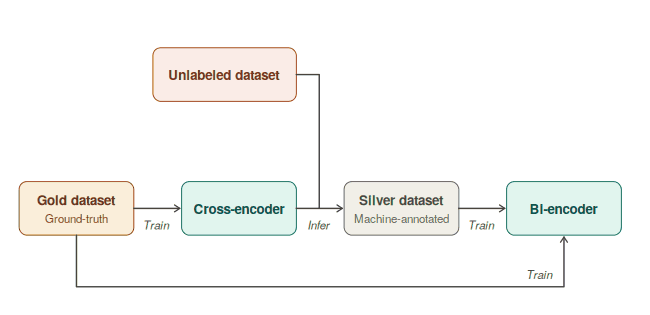

Let's simulate a setting where we have limited annotated data and take only 50,000 documents.

In [124]:
from sentence_transformers.cross_encoder import CrossEncoder, CrossEncoderTrainer, CrossEncoderTrainingArguments
from sentence_transformers.sentence_transformer.training_args import BatchSamplers

In [115]:
dataset = load_dataset("nyu-mll/glue", "mnli", split="train").select(range(50_000))

In [116]:
# give "entailment" a score of 1 whereas "neutral" and "contradiction" get a scope of 0.
mapping = {2: 0, 1: 0, 0: 1}

In [113]:
gold_dataset = (
    dataset
    .select_columns(["premise", "hypothesis", "label"])   # input columns in order, then label
    .map(lambda row: {"label": mapping[row["label"]]})
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [123]:
cross_encoder = CrossEncoder("answerdotai/ModernBERT-base", num_labels=2)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [119]:
args = CrossEncoderTrainingArguments(
    output_dir="models/nli-ce",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    bf16=True,
)

In [126]:
trainer = CrossEncoderTrainer(
    model=cross_encoder,
    args=args,
    train_dataset=gold_dataset,
)

In [127]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss
500,0.353850


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=939, training_loss=0.2273715123835717, metrics={'train_runtime': 105.7548, 'train_samples_per_second': 283.675, 'train_steps_per_second': 8.879, 'total_flos': 0.0, 'train_loss': 0.2273715123835717, 'epoch': 3.0})

After training our cross-encoder, we use the remaining sentence pairs as our silver dataset.  

In [130]:
silver = load_dataset("nyu-mll/glue", "mnli", split="train").select(range(10_000, 392_702 - 50_000))

In [131]:
pairs = list(zip(silver["premise"], silver["hypothesis"]))

In [132]:
silver[42]

{'premise': "I'd like to see how much Pa pushed into m' thick head.",
 'hypothesis': 'I want to know how much Pa has put into my head.',
 'label': 0,
 'idx': 10042}

We will assume that these sentence pairs are **unlabeled** in this example. We will use our fine-tuned cross-encoder to label these sentence pairs.  

In [137]:
# Labeling example
output = cross_encoder.predict(pairs, apply_softmax=True, show_progress_bar=True)

Batches:   0%|          | 0/10397 [00:00<?, ?it/s]

In [145]:
print(output)

[[5.5893488e-02 9.4410646e-01]
 [9.9999321e-01 6.8175364e-06]
 [9.9970728e-01 2.9267944e-04]
 ...
 [3.4715730e-04 9.9965286e-01]
 [9.9917299e-01 8.2702877e-04]
 [9.9996364e-01 3.6323159e-05]]


Now that we have **gold** and **silver** datasets we combine them into one and train our embedding model:

In [147]:
import numpy as np
import pandas as pd

In [139]:
gold = pd.DataFrame(
    {
        "sentence1": dataset["premise"],
        "sentence2": dataset["hypothesis"],
        "label": [mapping[label] for label in dataset["label"]]
    }
)

In [148]:
silver = pd.DataFrame(
    {
        "sentence1": silver["premise"],
        "sentence2": silver["hypothesis"],
        "label": np.argmax(output, axis=1)
    }
)

In [152]:
data = pd.concat([gold, silver], ignore_index=True, axis=0)
data = data.drop_duplicates(subset=["sentence1", "sentence2"], keep="first")

In [153]:
train_dataset = Dataset.from_pandas(data, preserve_index=False)

In [158]:
evaluator = EmbeddingSimilarityEvaluator(
    sentences1=val_sts["sentence1"],
    sentences2=val_sts["sentence2"],
    scores=[score/5 for score in val_sts["label"]],
    main_similarity="cosine",
)

In [159]:
embedding_model = SentenceTransformer(
    "answerdotai/ModernBERT-large"
)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [160]:
train_loss = losses.CosineSimilarityLoss(
    model=embedding_model
)

In [161]:
args = SentenceTransformerTrainingArguments(
    output_dir="data/base_embedding_after_on_cross_encoder_classification",
    num_train_epochs=1,
    
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    
    bf16=True,
    fp16=False,
    
    warmup_steps=1000,
    eval_steps=1000,
    logging_steps=1000
)

In [162]:
trainer = SentenceTransformerTrainer(
    model=embedding_model,
    args=args,
    train_dataset=train_dataset,
    loss=train_loss,
    evaluator=evaluator
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [163]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss
1000,0.174515
2000,0.132883
3000,0.124192
4000,0.121659
5000,0.116812
6000,0.113768
7000,0.112921
8000,0.110754
9000,0.109531
10000,0.106991


[W1003 18:17:04.964892737 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 138412032 bytes (free: 137494528, total: 33684389888).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10707, training_loss=0.12143950258815969, metrics={'train_runtime': 1533.5558, 'train_samples_per_second': 223.402, 'train_steps_per_second': 6.982, 'total_flos': 0.0, 'train_loss': 0.12143950258815969, 'epoch': 1.0})

In [164]:
evaluator(embedding_model)

{'pearson_cosine': 0.755865021451155, 'spearman_cosine': 0.7530848524521078}

We used only 50,000 records from the original dataset instead of using all records! The method allows us to increase the size of datasets without the need to manually label hundreds of thousands of sentence pairs.

The cross-encoder is the accurate-but-slow teacher, and the bi-encoder is the fast-but-data-hungry student.

Which pairs you label matters. Random pairs are almost all negatives, so Augmented SBERT usually picks candidates with BM25 or a semantic search before labeling.

# Unsupervised Learning

TSDAE's motivation was that labeled data is seldom available for most tasks and domains, and creating it is expensive. That premise has largely collapsed. LLM-generated training data now beats pure unsupervised objectives by a wide margin, and that is how most modern embedding models are trained.